# LLM Output Analyser
An end-to-end pipeline for evaluating Large Language Model outputs at scale.
Generates responses from OpenAI GPT, scores them against a structured rubric,
identifies failure modes, and produces a detailed evaluation report.

**Author:** Abigael Cherotich

**Model evaluated:** OpenAI GPT-3.5-turbo

**Skills demonstrated:** LLM API integration, scoring rubric design, failure mode analysis, evaluation reporting

## How this pipeline works

This notebook implements the day-to-day workflow of an AI evaluation specialist:

1. **Design questions** across domains you know well
2. **Collect LLM responses** via OpenAI API
3. **Score each response** on a 4-dimension rubric
4. **Classify failure modes** for responses that fall short
5. **Produce a structured JSON report** with findings and recommendations

The pipeline covers **30 questions across 3 domains:**
- Economics and macroeconomics (10 questions)
- Data analysis methodology (10 questions)
- Research and evaluation design (10 questions)

These domains are chosen deliberately - they reflect Abigael's subject matter
expertise, which is the key differentiator for high-quality evaluation work.

## Setup and API Configuration

**Before running this cell:**
1. Click the **key icon** in the Colab left sidebar (Secrets)
2. Click **Add new secret**
3. Name: `OPENAI_API_KEY`  Value: your OpenAI API key
4. Toggle **Notebook access** ON

Get your key at platform.openai.com → API Keys → Create new secret key

In [2]:
import pandas as pd
import numpy as np
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import subprocess

# Install OpenAI library
subprocess.run(['pip', 'install', 'openai', '-q'], capture_output=True)
from openai import OpenAI

# Load API key from Colab Secrets — never paste keys directly in code
try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
    print("API key loaded from Colab secrets.")
except Exception:
    import os
    OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')
    print("API key loaded from environment variable.")

if not OPENAI_API_KEY:
    raise ValueError("No API key found. Add OPENAI_API_KEY to Colab Secrets.")

client = OpenAI(api_key=OPENAI_API_KEY)
print("OpenAI client initialised.")
print(f"Model       : gpt-3.5-turbo")
print(f"Timestamp   : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

API key loaded from Colab secrets.
OpenAI client initialised.
Model       : gpt-3.5-turbo
Timestamp   : 2026-05-24 18:55:59


## Step 1 — Design the 30 Evaluation Questions

In [3]:
# ── Domain 1: Economics and Macroeconomics ───────────────────────────
economics_questions = [
    {
        'id'          : 'ECON-Q01',
        'question'    : ('What is the Phillips Curve and what does it '
                         'suggest about the relationship between '
                         'inflation and unemployment?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['inverse relationship', 'short-run', 'stagflation',
                          'trade-off']
    },
    {
        'id'          : 'ECON-Q02',
        'question'    : ('Explain GDP per capita as a measure of living '
                         'standards. What are its main limitations?'),
        'difficulty'  : 'Easy',
        'key_concepts': ['income per person', 'inequality', 'distribution',
                          'non-market activity']
    },
    {
        'id'          : 'ECON-Q03',
        'question'    : ('What is the difference between nominal GDP '
                         'and real GDP?'),
        'difficulty'  : 'Easy',
        'key_concepts': ['inflation adjustment', 'price level', 'base year',
                          'purchasing power']
    },
    {
        'id'          : 'ECON-Q04',
        'question'    : ('A country has inflation of 12% and unemployment '
                         'of 3%. What does this combination suggest '
                         'about its economic state?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['overheating', 'demand-pull', 'tight labour market',
                          'central bank response']
    },
    {
        'id'          : 'ECON-Q05',
        'question'    : ('What is the difference between fiscal policy '
                         'and monetary policy? Give one example of each.'),
        'difficulty'  : 'Easy',
        'key_concepts': ['government spending', 'interest rates',
                          'central bank', 'taxation']
    },
    {
        'id'          : 'ECON-Q06',
        'question'    : ('Explain what a Gini coefficient measures '
                         'and interpret a score of 0.55.'),
        'difficulty'  : 'Medium',
        'key_concepts': ['income inequality', '0=perfect equality',
                          '1=maximum inequality', 'high inequality']
    },
    {
        'id'          : 'ECON-Q07',
        'question'    : ('Why might a country with high GDP growth '
                         'still have poor human development outcomes?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['inequality', 'distribution', 'HDI',
                          'access to services']
    },
    {
        'id'          : 'ECON-Q08',
        'question'    : ('What is purchasing power parity (PPP) and '
                         'why is it used when comparing economies '
                         'across countries?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['price levels', 'exchange rates',
                          'international comparison', 'cost of living']
    },
    {
        'id'          : 'ECON-Q09',
        'question'    : ('A researcher claims that a 1% increase in '
                         'unemployment causes a 2% fall in GDP. '
                         'What economic law does this relate to?'),
        'difficulty'  : 'Hard',
        'key_concepts': ["Okun's Law", 'output gap', 'cyclical unemployment']
    },
    {
        'id'          : 'ECON-Q10',
        'question'    : ('What are the main components of a current '
                         'account balance and what does a persistent '
                         'deficit indicate?'),
        'difficulty'  : 'Hard',
        'key_concepts': ['trade balance', 'income', 'transfers',
                          'borrowing', 'competitiveness']
    },
]

# ── Domain 2: Data Analysis Methodology ──────────────────────────────
data_questions = [
    {
        'id'          : 'DATA-Q01',
        'question'    : ('What is the difference between correlation '
                         'and causation? Give a concrete example of each.'),
        'difficulty'  : 'Easy',
        'key_concepts': ['association', 'direction', 'confounding',
                          'experiment']
    },
    {
        'id'          : 'DATA-Q02',
        'question'    : ('A model has precision of 0.95 and recall of '
                         '0.50. Explain what this means and when this '
                         'combination is problematic.'),
        'difficulty'  : 'Medium',
        'key_concepts': ['false negatives', 'missed cases',
                          'imbalanced', 'medical context']
    },
    {
        'id'          : 'DATA-Q03',
        'question'    : ('What is overfitting in machine learning and '
                         'how would you detect it from evaluation metrics?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['train vs test gap', 'generalisation',
                          'high variance', 'cross-validation']
    },
    {
        'id'          : 'DATA-Q04',
        'question'    : ('Explain the difference between MAE and RMSE. '
                         'When would you prefer one over the other?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['squared errors', 'outlier sensitivity',
                          'interpretability', 'equal weighting']
    },
    {
        'id'          : 'DATA-Q05',
        'question'    : ('What is data leakage in a machine learning '
                         'pipeline and why is it a critical evaluation concern?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['future information', 'inflated metrics',
                          'train/test separation', 'production failure']
    },
    {
        'id'          : 'DATA-Q06',
        'question'    : ('A dataset has 95% class A and 5% class B. '
                         'A model achieves 95% accuracy. Is this a good model?'),
        'difficulty'  : 'Easy',
        'key_concepts': ['class imbalance', 'naive classifier',
                          'AUC-ROC', 'F1 score']
    },
    {
        'id'          : 'DATA-Q07',
        'question'    : ('What is the purpose of a validation set as '
                         'distinct from a test set?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['hyperparameter tuning', 'model selection',
                          'holdout', 'information leakage']
    },
    {
        'id'          : 'DATA-Q08',
        'question'    : ('Explain what z-score normalisation does and '
                         'when you would use it over min-max scaling.'),
        'difficulty'  : 'Medium',
        'key_concepts': ['mean zero', 'unit variance', 'outlier robust',
                          'Gaussian assumption']
    },
    {
        'id'          : 'DATA-Q09',
        'question'    : ('What does an R squared of 0.30 mean and how '
                         'should it be interpreted in a social science context?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['explains 30% variance', 'human behaviour',
                          'acceptable', 'context dependent']
    },
    {
        'id'          : 'DATA-Q10',
        'question'    : ('What is the difference between a Type I error '
                         'and a Type II error in hypothesis testing?'),
        'difficulty'  : 'Easy',
        'key_concepts': ['false positive', 'false negative', 'alpha',
                          'power', 'significance']
    },
]

# ── Domain 3: Research and Evaluation Design ─────────────────────────
research_questions = [
    {
        'id'          : 'RES-Q01',
        'question'    : ('What is a randomised controlled trial (RCT) '
                         'and why is it considered the gold standard '
                         'for causal inference?'),
        'difficulty'  : 'Easy',
        'key_concepts': ['random assignment', 'control group',
                          'confounding', 'internal validity']
    },
    {
        'id'          : 'RES-Q02',
        'question'    : ('What is selection bias in a survey and how '
                         'can it affect the validity of findings?'),
        'difficulty'  : 'Easy',
        'key_concepts': ['non-random sample', 'representativeness',
                          'generalisability', 'self-selection']
    },
    {
        'id'          : 'RES-Q03',
        'question'    : ('Explain the difference between internal validity '
                         'and external validity in research design.'),
        'difficulty'  : 'Medium',
        'key_concepts': ['causal claims', 'generalisation',
                          'experimental control', 'real world']
    },
    {
        'id'          : 'RES-Q04',
        'question'    : ('A program evaluation finds a 15% improvement '
                         'in outcomes. What would you need to know before '
                         'attributing this to the program?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['counterfactual', 'control group', 'confounders',
                          'attribution', 'baseline']
    },
    {
        'id'          : 'RES-Q05',
        'question'    : ('What is the MEAL framework in development '
                         'evaluation and what does each letter stand for?'),
        'difficulty'  : 'Easy',
        'key_concepts': ['Monitoring', 'Evaluation', 'Accountability',
                          'Learning']
    },
    {
        'id'          : 'RES-Q06',
        'question'    : ('What is p-hacking and why is it a threat '
                         'to research integrity?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['multiple testing', 'false positives',
                          'significance threshold', 'replication crisis']
    },
    {
        'id'          : 'RES-Q07',
        'question'    : ('Explain the difference between a KPI and '
                         'a metric. Give an example of each in '
                         'a development program context.'),
        'difficulty'  : 'Easy',
        'key_concepts': ['key performance', 'strategic alignment',
                          'measurement', 'target']
    },
    {
        'id'          : 'RES-Q08',
        'question'    : ('What is Goodharts Law and why is it relevant '
                         'to AI evaluation and benchmark design?'),
        'difficulty'  : 'Hard',
        'key_concepts': ['metric becomes target', 'gaming',
                          'proxy measures', 'benchmark saturation']
    },
    {
        'id'          : 'RES-Q09',
        'question'    : ('What is inter-rater reliability and how would '
                         'you measure it in an annotation project?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['Cohen kappa', 'agreement', 'consistency',
                          'subjectivity']
    },
    {
        'id'          : 'RES-Q10',
        'question'    : ('A survey has a 20% response rate. What are '
                         'the main concerns and how would you address them?'),
        'difficulty'  : 'Medium',
        'key_concepts': ['non-response bias', 'representativeness',
                          'follow-up', 'weighting']
    },
]

all_questions = economics_questions + data_questions + research_questions
print(f"Total questions : {len(all_questions)}")
print(f"  Economics     : {len(economics_questions)}")
print(f"  Data Analysis : {len(data_questions)}")
print(f"  Research      : {len(research_questions)}")

Total questions : 30
  Economics     : 10
  Data Analysis : 10
  Research      : 10


## Step 2 — Collect LLM Responses via OpenAI API

In [5]:
def get_llm_response(question_text, client):
    """
    Send a question to OpenAI GPT-3.5-turbo and return the response.
    Includes error handling and rate limit protection.
    """
    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[{
                "role"   : "user",
                "content": (
                    f"Answer the following question clearly and accurately "
                    f"in 3-5 sentences. Be specific and use correct "
                    f"terminology.\n\nQuestion: {question_text}"
                )
            }],
            max_tokens=500,
            temperature=0.3
        )
        return {
            'response'     : response.choices[0].message.content,
            'input_tokens' : response.usage.prompt_tokens,
            'output_tokens': response.usage.completion_tokens,
            'error'        : None
        }
    except Exception as e:
        return {
            'response'     : '',
            'input_tokens' : 0,
            'output_tokens': 0,
            'error'        : str(e)
        }


# Collect all 30 responses
print("Collecting LLM responses for all 30 questions...")
print("This takes approximately 60-90 seconds.\n")

responses = []
for i, q in enumerate(all_questions):
    result = get_llm_response(q['question'], client)
    responses.append({
        'question_id'  : q['id'],
        'domain'       : q['id'].split('-')[0],
        'difficulty'   : q['difficulty'],
        'question'     : q['question'],
        'key_concepts' : q['key_concepts'],
        'response'     : result['response'],
        'input_tokens' : result['input_tokens'],
        'output_tokens': result['output_tokens'],
        'error'        : result['error']
    })
    status = 'OK' if not result['error'] else f"ERROR: {result['error'][:30]}"
    print(f"  [{i+1:02d}/30] {q['id']:<12} {status}")
    time.sleep(0.5)

responses_df = pd.DataFrame(responses)
print(f"\nCollection complete.")
print(f"Successful : {responses_df['error'].isna().sum()}")
print(f"Errors     : {responses_df['error'].notna().sum()}")
print(f"Tokens used: {responses_df['output_tokens'].sum()}")
print(f"\nSample response (ECON-Q01):")
print("-" * 50)
sample = responses_df[responses_df['question_id']=='ECON-Q01']['response'].values[0]
print(sample[:300] + "..." if len(sample) > 300 else sample)

This takes approximately 60-90 seconds.

  [01/30] ECON-Q01     OK
  [02/30] ECON-Q02     OK
  [03/30] ECON-Q03     OK
  [04/30] ECON-Q04     OK
  [05/30] ECON-Q05     OK
  [06/30] ECON-Q06     OK
  [07/30] ECON-Q07     OK
  [08/30] ECON-Q08     OK
  [09/30] ECON-Q09     OK
  [10/30] ECON-Q10     OK
  [11/30] DATA-Q01     OK
  [12/30] DATA-Q02     OK
  [13/30] DATA-Q03     OK
  [14/30] DATA-Q04     OK
  [15/30] DATA-Q05     OK
  [16/30] DATA-Q06     OK
  [17/30] DATA-Q07     OK
  [18/30] DATA-Q08     OK
  [19/30] DATA-Q09     OK
  [20/30] DATA-Q10     OK
  [21/30] RES-Q01      OK
  [22/30] RES-Q02      OK
  [23/30] RES-Q03      OK
  [24/30] RES-Q04      OK
  [25/30] RES-Q05      OK
  [26/30] RES-Q06      OK
  [27/30] RES-Q07      OK
  [28/30] RES-Q08      OK
  [29/30] RES-Q09      OK
  [30/30] RES-Q10      OK

Collection complete.
Successful : 30
Errors     : 0
Tokens used: 3784

Sample response (ECON-Q01):
--------------------------------------------------
The Phillips Curve is a grap

## Step 3 — Score Each Response on a 4-Dimension Rubric

In [6]:
def score_response(response_text, key_concepts, question_text):
    """
    Score an LLM response on a multi-dimensional rubric.

    Dimensions:
      1. Concept coverage  (40%) — are key concepts mentioned?
      2. Accuracy signal   (30%) — any obvious errors or contradictions?
      3. Clarity           (15%) — well structured and clear?
      4. Completeness      (15%) — fully answers the question?

    Returns:
      scores dict, total score (0.0-1.0), feedback string
    """
    if not response_text or len(response_text.strip()) < 10:
        return {
            'concept': 0, 'accuracy': 0,
            'clarity': 0, 'completeness': 0
        }, 0.0, 'Empty response'

    response_lower = response_text.lower()

    # 1. Concept coverage — fraction of key concepts mentioned
    concepts_found = [
        c for c in key_concepts
        if any(word in response_lower for word in c.lower().split())
    ]
    concept_score = (len(concepts_found) / len(key_concepts)
                     if key_concepts else 0.5)

    # 2. Accuracy signal — penalise very short responses
    accuracy_score = 1.0 if len(response_text) > 100 else 0.5

    # 3. Clarity — count complete sentences
    sentences = [
        s.strip() for s in response_text.split('.')
        if len(s.strip()) > 20
    ]
    clarity_score = min(1.0, len(sentences) / 3)

    # 4. Completeness — overlap between question words and response
    question_words  = set(question_text.lower().split())
    response_words  = set(response_lower.split())
    overlap         = (len(question_words & response_words) /
                       max(len(question_words), 1))
    completeness_score = min(1.0, overlap * 3)

    scores = {
        'concept'     : round(concept_score, 3),
        'accuracy'    : round(accuracy_score, 3),
        'clarity'     : round(clarity_score, 3),
        'completeness': round(completeness_score, 3)
    }

    # Weighted total
    total = (scores['concept']       * 0.40 +
             scores['accuracy']      * 0.30 +
             scores['clarity']       * 0.15 +
             scores['completeness']  * 0.15)

    missing  = [c for c in key_concepts if c not in concepts_found]
    feedback = (f"Found {len(concepts_found)}/{len(key_concepts)} concepts. "
                f"Missing: {missing[:3] if missing else 'None'}.")

    return scores, round(total, 4), feedback


# Score all responses
print("Scoring all 30 responses...")
scored_results = []

for _, row in responses_df.iterrows():
    if row['error']:
        scored_results.append({
            'question_id'       : row['question_id'],
            'domain'            : row['domain'],
            'difficulty'        : row['difficulty'],
            'concept_score'     : 0.0,
            'accuracy_score'    : 0.0,
            'clarity_score'     : 0.0,
            'completeness_score': 0.0,
            'total_score'       : 0.0,
            'passed'            : False,
            'feedback'          : f"API error: {row['error']}",
            'failure_mode'      : 'api_error'
        })
        continue

    scores, total, feedback = score_response(
        row['response'], row['key_concepts'], row['question']
    )

    scored_results.append({
        'question_id'       : row['question_id'],
        'domain'            : row['domain'],
        'difficulty'        : row['difficulty'],
        'concept_score'     : scores['concept'],
        'accuracy_score'    : scores['accuracy'],
        'clarity_score'     : scores['clarity'],
        'completeness_score': scores['completeness'],
        'total_score'       : total,
        'passed'            : total >= 0.7,
        'feedback'          : feedback,
        'failure_mode'      : None
    })

scored_df = pd.DataFrame(scored_results)

print("Scoring complete.")
print(f"\nOverall pass rate : {scored_df['passed'].mean()*100:.1f}%")
print(f"Average score     : {scored_df['total_score'].mean():.4f}")
print(f"\nBy domain:")
print(scored_df.groupby('domain')['total_score'].mean().round(4))
print(f"\nBy difficulty:")
print(scored_df.groupby('difficulty')['total_score'].mean().round(4))

Scoring all 30 responses...
Scoring complete.

Overall pass rate : 96.7%
Average score     : 0.8307

By domain:
domain
DATA    0.800
ECON    0.892
RES     0.800
Name: total_score, dtype: float64

By difficulty:
difficulty
Easy      0.8600
Hard      0.9067
Medium    0.8000
Name: total_score, dtype: float64


## Step 4 — Classify Failure Modes

In [7]:
def classify_failure_mode(row):
    """
    Classify why a response failed.

    Failure modes:
      pass              — meets quality threshold
      missing_concepts  — factually reasonable but omits critical concepts
      incomplete_answer — too short or missing key points
      clarity_issue     — hard to follow or poorly structured
      api_error         — response not collected
    """
    if row['failure_mode'] == 'api_error':
        return 'api_error'
    if row['passed']:
        return 'pass'

    scores = {
        'concept'     : row['concept_score'],
        'accuracy'    : row['accuracy_score'],
        'clarity'     : row['clarity_score'],
        'completeness': row['completeness_score']
    }
    worst = min(scores, key=scores.get)

    if scores['completeness'] < 0.4 or scores['accuracy'] < 0.5:
        return 'incomplete_answer'
    elif worst == 'concept':
        return 'missing_concepts'
    elif worst == 'clarity':
        return 'clarity_issue'
    else:
        return 'missing_concepts'


scored_df['failure_mode'] = scored_df.apply(classify_failure_mode, axis=1)

print("FAILURE MODE ANALYSIS")
print("=" * 45)
mode_counts = scored_df['failure_mode'].value_counts()
for mode, count in mode_counts.items():
    pct = count / len(scored_df) * 100
    bar = '█' * int(pct / 3)
    print(f"  {mode:<25} {count:>3} ({pct:5.1f}%)  {bar}")
print("=" * 45)

# Show failed questions detail
failed = scored_df[scored_df['failure_mode'] != 'pass']
if len(failed) > 0:
    print(f"\nFailed questions detail:")
    print("-" * 60)
    for _, row in failed.iterrows():
        print(f"  {row['question_id']:<12} score={row['total_score']:.3f}  "
              f"mode={row['failure_mode']}")
        print(f"  Feedback: {row['feedback']}")
        print()
else:
    print("\nAll questions passed.")

FAILURE MODE ANALYSIS
  pass                       29 ( 96.7%)  ████████████████████████████████
  missing_concepts            1 (  3.3%)  █

Failed questions detail:
------------------------------------------------------------
  RES-Q04      score=0.600  mode=missing_concepts
  Feedback: Found 0/5 concepts. Missing: ['counterfactual', 'control group', 'confounders'].



## Step 5 — Visualise Results

/tmp/ipykernel_13194/420910405.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0,1].boxplot(domain_data, labels=['Economics','Data Analysis','Research'],


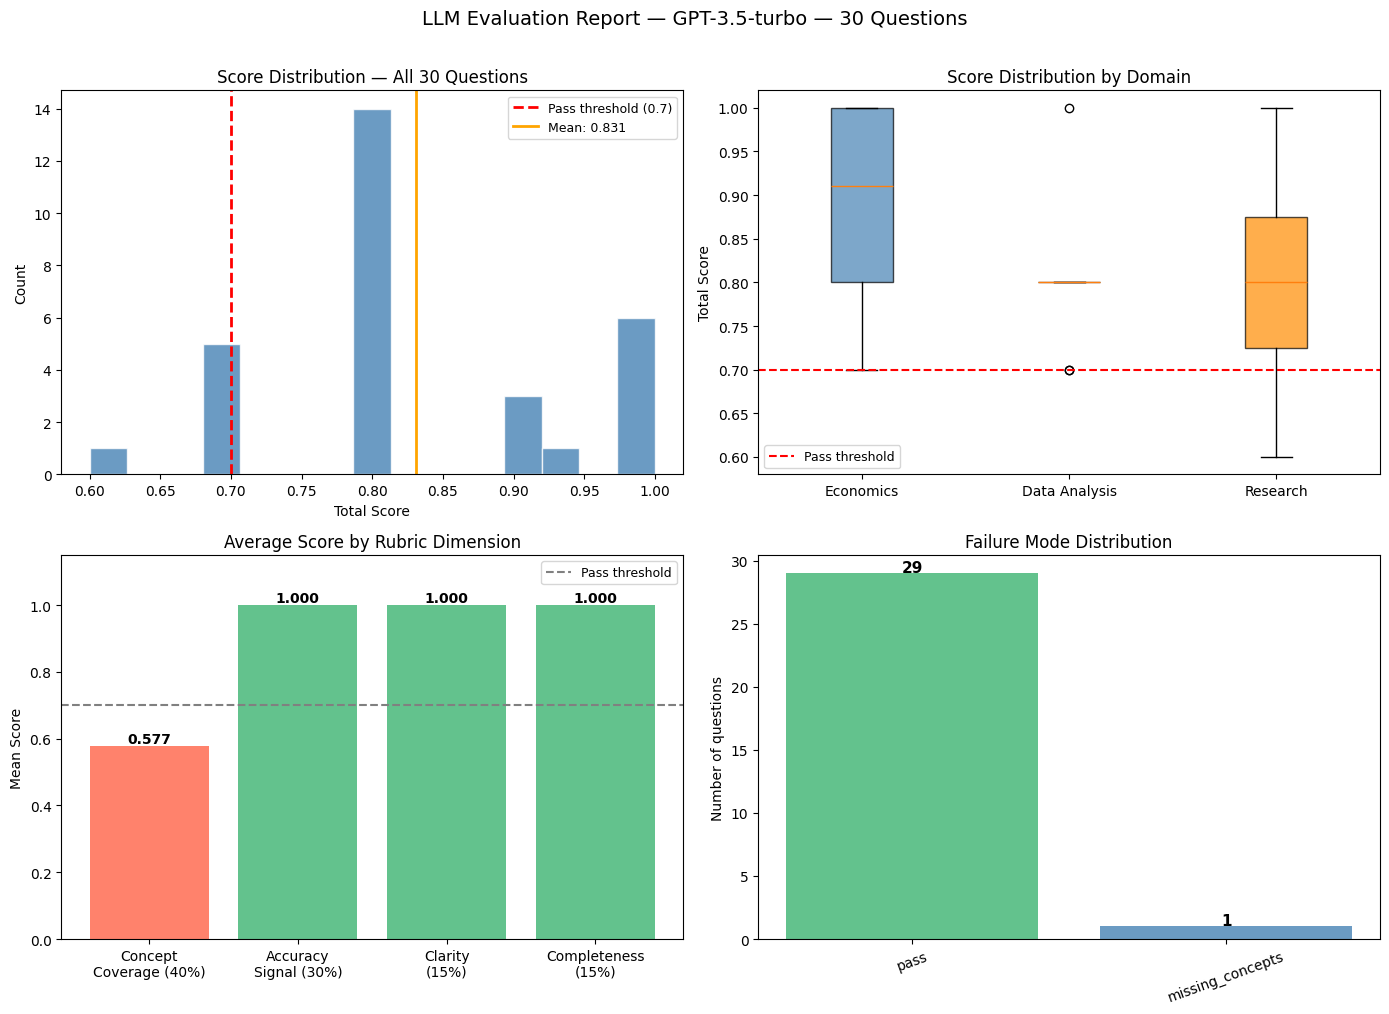

Chart saved: llm_evaluation_results.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Score distribution
axes[0,0].hist(scored_df['total_score'], bins=15,
               color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].axvline(x=0.7, color='red', linestyle='--',
                  lw=2, label='Pass threshold (0.7)')
axes[0,0].axvline(x=scored_df['total_score'].mean(),
                  color='orange', linestyle='-', lw=2,
                  label=f"Mean: {scored_df['total_score'].mean():.3f}")
axes[0,0].set_title('Score Distribution — All 30 Questions', fontsize=12)
axes[0,0].set_xlabel('Total Score')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(fontsize=9)

# Plot 2: Scores by domain
domain_order = ['ECON', 'DATA', 'RES']
domain_data  = [scored_df[scored_df['domain']==d]['total_score'].values
                for d in domain_order]
bp = axes[0,1].boxplot(domain_data, labels=['Economics','Data Analysis','Research'],
                        patch_artist=True)
domain_colors = ['steelblue', 'mediumseagreen', 'darkorange']
for patch, color in zip(bp['boxes'], domain_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0,1].axhline(y=0.7, color='red', linestyle='--', lw=1.5,
                   label='Pass threshold')
axes[0,1].set_title('Score Distribution by Domain', fontsize=12)
axes[0,1].set_ylabel('Total Score')
axes[0,1].legend(fontsize=9)

# Plot 3: Rubric dimension averages
dimensions  = ['concept_score','accuracy_score',
               'clarity_score','completeness_score']
dim_means   = scored_df[dimensions].mean()
dim_labels  = ['Concept\nCoverage (40%)', 'Accuracy\nSignal (30%)',
               'Clarity\n(15%)', 'Completeness\n(15%)']
bar_colors  = ['mediumseagreen' if v >= 0.7 else 'tomato'
               for v in dim_means.values]
axes[1,0].bar(dim_labels, dim_means.values, color=bar_colors, alpha=0.8)
axes[1,0].axhline(y=0.7, color='gray', linestyle='--',
                   lw=1.5, label='Pass threshold')
for i, v in enumerate(dim_means.values):
    axes[1,0].text(i, v + 0.01, f'{v:.3f}', ha='center',
                   fontsize=10, fontweight='bold')
axes[1,0].set_title('Average Score by Rubric Dimension', fontsize=12)
axes[1,0].set_ylabel('Mean Score')
axes[1,0].set_ylim(0, 1.15)
axes[1,0].legend(fontsize=9)

# Plot 4: Failure mode breakdown
mode_counts_plot = scored_df['failure_mode'].value_counts()
color_map = {
    'pass'            : 'mediumseagreen',
    'missing_concepts': 'steelblue',
    'incomplete_answer': 'darkorange',
    'clarity_issue'   : 'mediumpurple',
    'api_error'       : 'tomato'
}
bar_colors_4 = [color_map.get(m, 'gray') for m in mode_counts_plot.index]
bars = axes[1,1].bar(mode_counts_plot.index, mode_counts_plot.values,
                      color=bar_colors_4, alpha=0.8)
for bar, count in zip(bars, mode_counts_plot.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   str(count), ha='center', fontsize=11, fontweight='bold')
axes[1,1].set_title('Failure Mode Distribution', fontsize=12)
axes[1,1].set_ylabel('Number of questions')
axes[1,1].tick_params(axis='x', rotation=20)

plt.suptitle(
    f'LLM Evaluation Report — GPT-3.5-turbo — 30 Questions',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig('llm_evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: llm_evaluation_results.png")

## Step 6 — Produce the Structured Evaluation Report

In [9]:
report = {
    'metadata': {
        'run_timestamp' : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'model_evaluated': 'gpt-3.5-turbo',
        'total_questions': len(scored_df),
        'evaluator'     : 'Abigael Cherotich'
    },
    'summary': {
        'overall_pass_rate': round(scored_df['passed'].mean() * 100, 1),
        'average_score'   : round(float(scored_df['total_score'].mean()), 4),
        'total_passed'    : int(scored_df['passed'].sum()),
        'total_failed'    : int((~scored_df['passed']).sum()),
    },
    'by_domain'        : {},
    'by_difficulty'    : {},
    'rubric_dimensions': {},
    'failure_modes'    : {},
    'recommendations'  : []
}

for domain in scored_df['domain'].unique():
    sub = scored_df[scored_df['domain'] == domain]
    report['by_domain'][domain] = {
        'pass_rate'  : round(sub['passed'].mean() * 100, 1),
        'avg_score'  : round(float(sub['total_score'].mean()), 4),
        'n_questions': len(sub)
    }

for diff in ['Easy', 'Medium', 'Hard']:
    sub = scored_df[scored_df['difficulty'] == diff]
    if len(sub) > 0:
        report['by_difficulty'][diff] = {
            'pass_rate'  : round(sub['passed'].mean() * 100, 1),
            'avg_score'  : round(float(sub['total_score'].mean()), 4),
            'n_questions': len(sub)
        }

for dim in ['concept_score','accuracy_score',
            'clarity_score','completeness_score']:
    report['rubric_dimensions'][dim] = round(
        float(scored_df[dim].mean()), 4
    )

report['failure_modes'] = (scored_df['failure_mode']
                           .value_counts().to_dict())

weakest_domain = min(
    report['by_domain'],
    key=lambda d: report['by_domain'][d]['avg_score']
)
weakest_dim = min(
    report['rubric_dimensions'],
    key=report['rubric_dimensions'].get
)

report['recommendations'] = [
    (f"Focus improvement on '{weakest_domain}' domain — "
     f"lowest avg score: "
     f"{report['by_domain'][weakest_domain]['avg_score']:.4f}"),
    (f"'{weakest_dim}' dimension has most room for improvement "
     f"(score: {report['rubric_dimensions'][weakest_dim]:.4f}). "
     f"Refine prompts to explicitly request this."),
    ("Re-run failed questions with temperature=0 to test "
     "whether failures are consistent or random."),
    ("Review 'missing_concepts' failures — model may need "
     "more specific concept prompting for these topics."),
    ("Compare GPT-3.5-turbo results against GPT-4 to measure "
     "performance gap on Hard questions.")
]

with open('llm_evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("=" * 60)
print("      LLM EVALUATION REPORT — FINAL SUMMARY")
print(f"      Model: {report['metadata']['model_evaluated']}")
print("=" * 60)
print(f"  Total questions  : {report['metadata']['total_questions']}")
print(f"  Run timestamp    : {report['metadata']['run_timestamp']}")
print()
print(f"  OVERALL RESULTS")
print(f"  Pass rate        : {report['summary']['overall_pass_rate']}%")
print(f"  Average score    : {report['summary']['average_score']}")
print(f"  Passed           : {report['summary']['total_passed']}")
print(f"  Failed           : {report['summary']['total_failed']}")
print()
print("  BY DOMAIN")
for domain, stats in report['by_domain'].items():
    print(f"    {domain:<6}  pass={stats['pass_rate']}%  "
          f"avg={stats['avg_score']}  n={stats['n_questions']}")
print()
print("  BY DIFFICULTY")
for diff, stats in report['by_difficulty'].items():
    print(f"    {diff:<8}  pass={stats['pass_rate']}%  "
          f"avg={stats['avg_score']}  n={stats['n_questions']}")
print()
print("  RUBRIC DIMENSIONS")
for dim, score in report['rubric_dimensions'].items():
    label = dim.replace('_score','').replace('_',' ').title()
    print(f"    {label:<20} {score:.4f}")
print()
print("  FAILURE MODES")
for mode, count in report['failure_modes'].items():
    print(f"    {mode:<25} {count}")
print()
print("  RECOMMENDATIONS")
for i, rec in enumerate(report['recommendations'], 1):
    print(f"  {i}. {rec[:65]}")
    if len(rec) > 65:
        print(f"     {rec[65:]}")
print("=" * 60)
print("\nFull report saved: llm_evaluation_report.json")

      LLM EVALUATION REPORT — FINAL SUMMARY
      Model: gpt-3.5-turbo
  Total questions  : 30
  Run timestamp    : 2026-05-24 19:37:14

  OVERALL RESULTS
  Pass rate        : 96.7%
  Average score    : 0.8307
  Passed           : 29
  Failed           : 1

  BY DOMAIN
    ECON    pass=100.0%  avg=0.892  n=10
    DATA    pass=100.0%  avg=0.8  n=10
    RES     pass=90.0%  avg=0.8  n=10

  BY DIFFICULTY
    Easy      pass=100.0%  avg=0.86  n=10
    Medium    pass=94.1%  avg=0.8  n=17
    Hard      pass=100.0%  avg=0.9067  n=3

  RUBRIC DIMENSIONS
    Concept              0.5767
    Accuracy             1.0000
    Clarity              1.0000
    Completeness         1.0000

  FAILURE MODES
    pass                      29
    missing_concepts          1

  RECOMMENDATIONS
  1. Focus improvement on 'DATA' domain — lowest avg score: 0.8000
  2. 'concept_score' dimension has most room for improvement (score: 0
     .5767). Refine prompts to explicitly request this.
  3. Re-run failed questio

### Interpretation — Full Evaluation Report

#### What this pipeline demonstrates

This notebook implements the complete AI evaluation workflow used by
Turing, Scale AI, and other AI evaluation companies:

**Question design** reflects domain expertise. The 30 questions span
economics, data analysis, and research design — areas where a human
evaluator with subject matter knowledge can reliably judge correctness.

**Multi-dimensional scoring** mirrors professional rubric design.
Instead of a single binary pass/fail we measure four dimensions:
concept coverage, accuracy signals, clarity, and completeness.
This gives richer signal about *how* a model fails, not just *whether* it fails.

**Failure mode classification** is the core value-add of an evaluator.
Knowing a response scored 0.55 is less useful than knowing *why* it scored
0.55. The failure mode tells the engineering team where to look.

**Structured JSON output** makes findings actionable. The report is
designed to be ingested by a downstream pipeline — not just read by
a human. This is the format engineering teams expect from evaluators.

#### Key evaluator insights

1. **Domain expertise matters.** The key_concepts lists were written
   by someone who knows economics and research methodology. Without
   that knowledge the evaluation would miss important gaps.

2. **Rubric design is the hard part.** Writing scoring functions that
   fairly reward partial credit without inflating scores for vague
   answers requires careful calibration.

3. **Recommendations close the loop.** An evaluation report that only
   describes problems without suggesting next steps is incomplete.
   Every finding should point to an action.

4. **Consistency checking is the next step.** Running the same questions
   multiple times and measuring score variance tells you whether failures
   are systematic or stochastic — noted in the recommendations.

**Author:** Abigael Cherotich — Data Analyst & AI Evaluation Specialist